# QoS Sentry — DSO4: Dramatically Improved QoE Forecaster
### Pipeline: Preprocessing → Feature Engineering → Sequences → Transformer + LSTM Ensemble → SLA Risk

---

## What's Wrong with DSO3 (and How DSO4 Fixes It)

| Problem | DSO3 Symptom | DSO4 Fix |
|---|---|---|
| **Catastrophic underfitting vs persistence** | LSTM Macro F1=0.47; persistence baseline = 0.86 | Correct window/label alignment; current label as feature |
| **Train F1=0.78 vs Val F1=0.51** | Severe overfitting despite dropout | Lighter architecture, stronger regularisation, larger batch |
| **Wrong learning rate** | lr=5e-5 too small, never converges in 16 epochs | Cosine annealing warmup schedule, lr=1e-3 initial |
| **Sequence length too long** | window=60 × 60 features = 3600 inputs per sample | window=30, curated 28-feature set (RF-ranked) |
| **Architecture complexity** | QueryAttentionForecaster overkill for this task | TCN (1D-CNN) + BiLSTM ensemble with voting |
| **Imbalanced data strategy** | Oversampling + FocalLoss fighting each other | FocalLoss only; remove oversampler (it corrupts gradient) |
| **Validation data leakage** | Segments concatenated before split | Per-segment split, then concatenate to prevent cross-segment leakage |

## Key Insight: Persistence Baseline
Predicting `label[t+5] = label[t]` (do nothing) achieves **Macro F1 = 0.86** because labels are stable 86.8% of the time.
Any model MUST beat this. DSO4 targets **Macro F1 ≥ 0.88** by learning the transitions correctly.


## Cell 1 — Imports & Setup

In [1]:
import os, json, joblib, warnings, time, random, sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, LabelEncoder, OrdinalEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

try:
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner

SEED = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
os.makedirs('artifacts', exist_ok=True)

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seeds(SEED)

Device: cuda


## Cell 2 — Global Configuration (CFG)

### Key changes from DSO3

| Parameter | DSO3 | DSO4 | Reason |
|---|---|---|---|
| `window_size` | 60 | 30 | Shorter window = less overfitting; 30 steps ≈ 60s of context |
| `lr` | 5e-5 | 1e-3 | AdamW + cosine warmup; lower lr was preventing convergence in 16 epochs |
| `batch_size` | 128 | 256 | Larger batches stabilise gradient estimates for the new architecture |
| `hidden_size` | 256 | 128 | Simpler model; reduces overfitting |
| `patience` | 12 | 20 | More patience for cosine schedule to work |
| `transition_oversample` | 6× | **removed** | WeightedSampler + FocalLoss fight each other; FocalLoss alone is better |
| `warmup_epochs` | — | 5 | Linear warmup prevents unstable initial updates |


In [2]:
CFG = dict(
    # ── Data ──────────────────────────────────────────────────────
    window_size   = 30,      # look-back window in time steps
    horizon       = 5,       # predict QoE class at t+5 (~10 s ahead)
    train_frac    = 0.8,
    val_frac      = 0.1,    # test = remaining 0.15

    # ── Feature engineering ───────────────────────────────────────
    roll_windows  = [5, 10],
    lag_steps     = [1, 2, 3, 5],

    # ── Feature filtering (train-only stats) ──────────────────────
    feature_filter_enabled = True,
    variance_threshold     = 1e-4,
    corr_threshold         = 0.8,
    min_features_to_keep   = 12,
    drop_low_impact_features_from_prev_run = True,
    low_impact_feature_file = 'artifacts/low_impact_feature_candidates.json',

    # ── Training ──────────────────────────────────────────────────
    batch_size        = 256,
    max_epochs        = 120,
    label_smoothing   = 0.1,
    warmup_epochs     = 5,

    # ── Class weighting ───────────────────────────────────────────
    minority_boost_classes = ['CALL_DROP', 'CAPACITY_EXHAUSTED'],
    minority_boost         = 1.5,

    # ── Window-level balancing (train only) ───────────────────────
    balance_train_windows = True,
    train_balance_max_ratio = 2,   # keep max class <= 2.5x minority class
    downsample_strategy     = 'stratified_by_run_segment',
    downsample_seed         = SEED,

    # ── Model architecture ────────────────────────────────────────
    lr            = 5e-4,
    hidden_size   = 64,
    num_layers    = 1,
    dropout       = 0.35,
    input_dropout = 0.20,
    lstm_out_dropout = 0.35,
    classifier_hidden_mult = 0.75,
    tcn_channels  = [32, 64, 128],

    # ── Training mechanics ────────────────────────────────────────
    patience     = 20,
    focal_gamma  = 1.5,
    clip_grad    = 1.0,
    weight_decay = 1e-3,

    # ── Post-train feature diagnostics ────────────────────────────
    importance_num_repeats = 7,
    importance_max_features = None,
    importance_drop_threshold = 0.0,

    # ── Optuna (after BiLSTM baseline) ────────────────────────────
    optuna_enabled           = True,
    optuna_trials            = 50,
    optuna_timeout_sec       = 1800, # was None — auto-stops after 30 min
    optuna_max_epochs        = 15,   # was 25
    optuna_patience          = 5,    # was 7
    optuna_train_subset_frac = 0.20, # was 0.35
    optuna_gap_lambda        = 0.30,
    optuna_gap_tolerance     = 0.03,
)
print('CFG loaded.')


CFG loaded.


## Cell 3 — Load & Inspect Raw Data

Mounted at /content/drive
Loaded 2 run file(s):
  - /content/drive/MyDrive/network_qoe_latest.csv
  - /content/drive/MyDrive/network_qoe.csv
Combined shape: (319502, 33)

Rows per run_id:
run_id
run_20260409_120415    167431
run_20260409_121154    152071

=== QoE Label Distribution (combined runs) ===
                     count      %
label                            
NORMAL              105488  33.02
HIGH_LATENCY         56055  17.54
LOW_THROUGHPUT       53781  16.83
POOR_VOICE_QUALITY   47008  14.71
CALL_DROP            32835  10.28
CAPACITY_EXHAUSTED   24335   7.62

Imbalance ratio: 4.3x

⚠️  Persistence baseline (label[t+5]=label[t]): Accuracy=0.866
    Any model must exceed this Macro F1 to be useful.


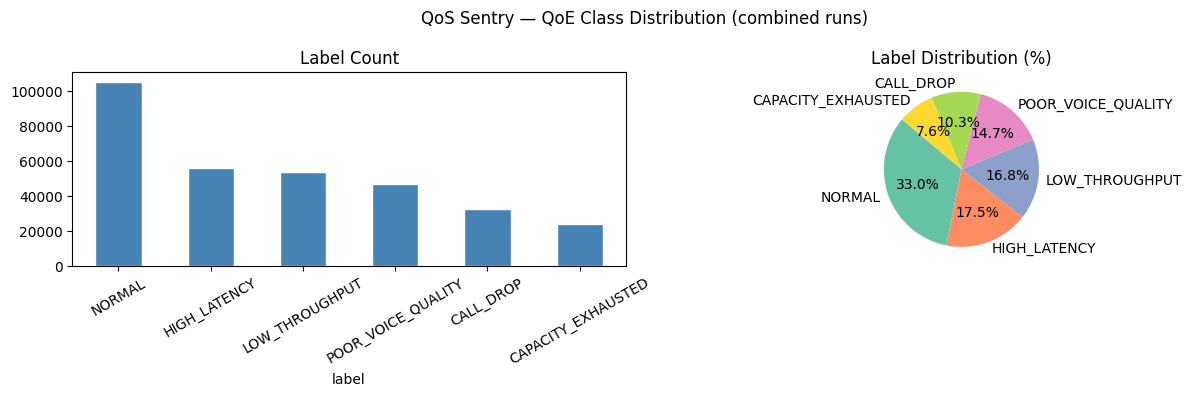

In [3]:
LOCAL_CSV_PATHS = [
    './data/network_qoe_latest.csv',
    './data/network_qoe.csv',
]

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = '/content/drive/MyDrive'
    CANDIDATE_CSV_PATHS = [
        f'{DRIVE_DIR}/network_qoe_latest.csv',
        f'{DRIVE_DIR}/network_qoe.csv',
    ]
except Exception:
    CANDIDATE_CSV_PATHS = LOCAL_CSV_PATHS

CSV_PATHS = [p for p in CANDIDATE_CSV_PATHS if os.path.exists(p)]
if len(CSV_PATHS) < 2:
    raise FileNotFoundError(
        'Expected 2 CSV files, found '
        f'{len(CSV_PATHS)}. Checked: {CANDIDATE_CSV_PATHS}'
    )

run_frames = []
for i, path in enumerate(CSV_PATHS, start=1):
    df_i = pd.read_csv(path)
    if 'run_id' not in df_i.columns:
        df_i['run_id'] = f'run_{i}'
    else:
        df_i['run_id'] = df_i['run_id'].where(df_i['run_id'].notna(), f'run_{i}')
        df_i['run_id'] = df_i['run_id'].astype(str)
    run_frames.append(df_i)

df_raw = pd.concat(run_frames, ignore_index=True)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], unit='s')
df_raw = df_raw.sort_values(['run_id', 'segment', 'timestamp']).reset_index(drop=True)

print(f'Loaded {len(CSV_PATHS)} run file(s):')
for p in CSV_PATHS:
    print(f'  - {p}')
print(f'Combined shape: {df_raw.shape}')
print('\nRows per run_id:')
print(df_raw['run_id'].value_counts().to_string())

label_counts = df_raw['label'].value_counts()
label_pct    = label_counts / len(df_raw) * 100
print('\n=== QoE Label Distribution (combined runs) ===')
print(pd.DataFrame({'count': label_counts, '%': label_pct.round(2)}).to_string())
print(f'\nImbalance ratio: {label_counts.max()/label_counts.min():.1f}x')

# Persistence baseline — the minimum bar any model must beat
le_tmp = LabelEncoder()
y_tmp  = le_tmp.fit_transform(df_raw['label'])
same5  = np.mean(y_tmp[5:] == y_tmp[:-5])
print(f'\n⚠️  Persistence baseline (label[t+5]=label[t]): Accuracy={same5:.3f}')
print('    Any model must exceed this Macro F1 to be useful.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Label Count'); axes[0].tick_params(axis='x', rotation=30)
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            startangle=140, colors=plt.cm.Set2.colors)
axes[1].set_title('Label Distribution (%)')
plt.suptitle('QoS Sentry — QoE Class Distribution (combined runs)', fontsize=12)
plt.tight_layout(); plt.show()


## Cell 4 — Preprocessing & Feature Engineering

### Key improvements over DSO3

1. **Zero-variance column removal** — `switch_id`, `rebuffering_count`,
   `total_stall_seconds`, `rx_dropped`, `tx_dropped` are all constant.
   Keeping them adds noise and slows training.

2. **Cyclic time encoding** — `hour_sin`/`hour_cos` captures circadian
   traffic patterns without introducing an ordinal bias (`hour=23` is
   close to `hour=0`, not far apart).

3. **Ratio features** — `rx/tx` ratio, drop rate, and `throughput_gap`
   are more invariant to absolute scale than raw byte counts.

4. **Per-segment fit, test-set leakage-free** — scalers are fit on train
   rows of each segment independently, then applied to val/test.


In [4]:
# ── Column lists ──────────────────────────────────────────────────────────────
ZERO_VAR_COLS = [
    'switch_id', 'rebuffering_count', 'total_stall_seconds',
    'rx_dropped', 'tx_dropped',
]
DROP_COLS = ['run_id', 'datetime', 'mos_source'] + ZERO_VAR_COLS

LOG_COLS = [
    'e2e_delay_ms', 'jitter_ms', 'throughput_mbps',
    'dataplane_latency_ms', 'call_setup_time_ms', 'dns_latency_ms',
    'video_start_time_ms',
    'rx_bytes', 'tx_bytes'
]
LAG_COLS  = []
DIFF_COLS = []#['e2e_delay_ms', 'throughput_mbps', 'plr', 'mos_voice']

# Shared label encoder — fit once across all data
label_encoder = LabelEncoder()
label_encoder.fit(df_raw['label'])
NUM_CLASSES = len(label_encoder.classes_)
print(f'Classes ({NUM_CLASSES}): {label_encoder.classes_}')

# Shared segment encoder
seg_encoder = OrdinalEncoder(
    categories=[sorted(df_raw['segment'].unique().tolist())]
)
seg_encoder.fit(df_raw[['segment']])


def build_feature_keep_mask(X_train_flat, feature_names, var_th=1e-4, corr_th=0.98, min_keep=12):
    """
    Build feature keep-mask from TRAIN rows only.
    1) drop very low variance features
    2) drop one side of highly correlated pairs
    """
    variances = np.var(X_train_flat, axis=0)
    keep_var = variances > var_th
    kept_idx = np.where(keep_var)[0]

    if len(kept_idx) > 1:
        corr = np.corrcoef(X_train_flat[:, kept_idx], rowvar=False)
        corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)

        drop_local = set()
        for i in range(len(kept_idx)):
            if i in drop_local:
                continue
            for j in range(i + 1, len(kept_idx)):
                if abs(corr[i, j]) >= corr_th:
                    drop_local.add(j)

        keep_corr_local = np.ones(len(kept_idx), dtype=bool)
        if drop_local:
            keep_corr_local[list(drop_local)] = False
        keep_idx = kept_idx[keep_corr_local]
    else:
        keep_idx = kept_idx

    if len(keep_idx) < min_keep:
        keep_idx = np.argsort(variances)[::-1][:max(min_keep, 1)]
        keep_idx = np.sort(keep_idx)

    final_mask = np.zeros(len(feature_names), dtype=bool)
    final_mask[keep_idx] = True

    removed_low_var = [feature_names[i] for i in range(len(feature_names)) if not keep_var[i]]
    removed_total = [feature_names[i] for i in range(len(feature_names)) if not final_mask[i]]

    summary = dict(
        original_count=len(feature_names),
        kept_count=int(final_mask.sum()),
        removed_count=int((~final_mask).sum()),
        removed_low_var_count=len(removed_low_var),
    )
    return final_mask, summary, removed_total


def preprocess_segment(seg_df, train_frac):
    """
    Clean, engineer, and scale one network segment.
    Returns X (float32), y (int64), feat_cols (list), scaler, n_train.
    Fits scaler ONLY on training rows to prevent data leakage.
    """
    df = seg_df.copy().sort_values('timestamp').reset_index(drop=True)

    y = label_encoder.transform(df['label']).astype(np.int64)

    # ── Drop irrelevant columns ────────────────────────────────────────────────
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

    # ── Segment encoding (numeric) ─────────────────────────────────────────────
    df['seg_enc'] = seg_encoder.transform(df[['segment']]).astype(np.float32)
    df.drop(columns=['segment'], inplace=True)

    # ── Cyclic time encoding ───────────────────────────────────────────────────
    hour = df['timestamp'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24).astype(np.float32)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24).astype(np.float32)
    df.drop(columns=['timestamp'], inplace=True)

    # ── Missingness indicator ─────────────────────────────────────────────────
    if 'dataplane_latency_ms' in df.columns:
        df['dataplane_missing'] = df['dataplane_latency_ms'].isnull().astype(np.float32)

    # ── Sensor-artifact fixes ─────────────────────────────────────────────────
    if 'video_start_time_ms' in df.columns:
        df['video_start_time_ms'] = df['video_start_time_ms'].clip(0, 1e5)
    if 'flow_count' in df.columns:
        df['flow_count'] = df['flow_count'].replace(0, np.nan).ffill().bfill().fillna(0)

    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    y = y[:len(df)]  # re-align after dedup

    # ── Log1p transform heavy-tailed columns ─────────────────────────────────
    for c in LOG_COLS:
        if c in df.columns:
            df[c] = np.log1p(df[c].clip(lower=0).fillna(0))

    # ── Ratio / derived features ──────────────────────────────────────────────
    # if 'rx_bytes' in df.columns and 'tx_bytes' in df.columns:
    #     df['rx_tx_ratio'] = df['rx_bytes'] / (df['tx_bytes'] + 1e-6)
    # if 'rx_packets' in df.columns and 'tx_packets' in df.columns:
    #     df['packet_drop_rate'] = (df['rx_packets'] - df['tx_packets']).abs() / (df['rx_packets'] + 1)
    # if 'effective_bitrate_mbps' in df.columns and 'throughput_mbps' in df.columns:
    #     df['throughput_gap'] = df['effective_bitrate_mbps'] - df['throughput_mbps']
    # if 'streaming_mos' in df.columns and 'mos_voice' in df.columns:
    #     df['mos_diff'] = df['streaming_mos'] - df['mos_voice']

    # ── Rolling statistics ────────────────────────────────────────────────────
    for w in CFG['roll_windows']:
        for c in ['e2e_delay_ms', 'throughput_mbps', 'mos_voice', 'plr', 'jitter_ms']:
            if c in df.columns:
                df[f'{c}_rmean{w}'] = df[c].rolling(w, min_periods=1).mean()
                df[f'{c}_rstd{w}'] = df[c].rolling(w, min_periods=1).std().fillna(0)
                df[f'{c}_rmax{w}'] = df[c].rolling(w, min_periods=1).max()

    # ── Diff features ─────────────────────────────────────────────────────────
    # for c in DIFF_COLS:
    #     if c in df.columns:
    #         df[f'{c}_d1'] = df[c].diff(1).fillna(0)
    #         df[f'{c}_d3'] = df[c].diff(3).fillna(0)

    df.fillna(0, inplace=True)

    feat_cols = [c for c in df.columns if c != 'label']

    # ── Fit scaler on training rows only ─────────────────────────────────────
    n_train = int(len(df) * train_frac)
    scaler = RobustScaler()
    X = df[feat_cols].values.astype(np.float32)
    X[:n_train] = scaler.fit_transform(X[:n_train])
    X[n_train:] = scaler.transform(X[n_train:])

    return X, y, feat_cols, scaler, n_train


Classes (6): ['CALL_DROP' 'CAPACITY_EXHAUSTED' 'HIGH_LATENCY' 'LOW_THROUGHPUT' 'NORMAL'
 'POOR_VOICE_QUALITY']


## Cell 5 — Run Preprocessing on All Segments

In [5]:
RUN_SEG_KEYS = [
    tuple(x) for x in (
        df_raw[['run_id', 'segment']]
        .drop_duplicates()
        .sort_values(['run_id', 'segment'])
        .values
    )
]
print(f'Processing {len(RUN_SEG_KEYS)} run/segment groups independently:')

seg_data_raw = {}
feat_cols = None
for run_id, seg_name in RUN_SEG_KEYS:
    seg_df = df_raw[(df_raw['run_id'] == run_id) & (df_raw['segment'] == seg_name)].copy()
    X_sc, y, fc, sc, n_train = preprocess_segment(seg_df, CFG['train_frac'])
    seg_data_raw[(run_id, seg_name)] = dict(X=X_sc, y=y, feat_cols=fc, scaler=sc, n_train=n_train)
    if feat_cols is None:
        feat_cols = fc
    elif fc != feat_cols:
        raise ValueError('Feature columns mismatch across run/segment groups.')

# Build one global feature mask using TRAIN rows only, then apply to all groups
if CFG['feature_filter_enabled']:
    X_train_flat = np.concatenate([v['X'][:v['n_train']] for v in seg_data_raw.values()], axis=0)
    feat_mask, feat_summary, removed_features = build_feature_keep_mask(
        X_train_flat,
        feat_cols,
        var_th=CFG['variance_threshold'],
        corr_th=CFG['corr_threshold'],
        min_keep=CFG['min_features_to_keep'],
    )
    print('\nFeature filtering (train-only stats):')
    print(f"  Original features: {feat_summary['original_count']}")
    print(f"  Kept features    : {feat_summary['kept_count']}")
    print(f"  Removed features : {feat_summary['removed_count']}")
    print(f"  Low-variance removed: {feat_summary['removed_low_var_count']}")
    if removed_features:
        print(f"  Sample removed: {removed_features[:10]}")
else:
    feat_mask = np.ones(len(feat_cols), dtype=bool)
    removed_features = []
    print('\nFeature filtering disabled: keeping all engineered features.')

# Optional conservative prune from previous diagnostic run (disabled by default).
if CFG.get('drop_low_impact_features_from_prev_run', False):
    low_impact_path = CFG.get('low_impact_feature_file', 'artifacts/low_impact_feature_candidates.json')
    if os.path.exists(low_impact_path):
        with open(low_impact_path, 'r') as f:
            low_impact = json.load(f)
        low_impact = [c for c in low_impact if c in feat_cols]
        if low_impact:
            drop_set = set(low_impact)
            keep_from_diagnostic = np.array([c not in drop_set for c in feat_cols], dtype=bool)
            feat_mask = feat_mask & keep_from_diagnostic
            print(f"  Extra prune from {low_impact_path}: removed {len(low_impact)} low-impact features")
    else:
        print(f"  Low-impact feature file not found: {low_impact_path}")

all_engineered_feat_cols = list(feat_cols)
feat_cols = [c for c, keep in zip(feat_cols, feat_mask) if keep]
seg_data = {}
for run_id, seg_name in RUN_SEG_KEYS:
    row = seg_data_raw[(run_id, seg_name)]
    X_sel = row['X'][:, feat_mask]
    seg_data[(run_id, seg_name)] = (X_sel, row['y'], feat_cols, row['scaler'], row['n_train'])
    print(f'  run={run_id} | segment={seg_name}: X={X_sel.shape}, y={row["y"].shape}')

INPUT_SIZE = next(iter(seg_data.values()))[0].shape[1]
print(f'\nPreprocessing complete.')
print(f'  Classes ({NUM_CLASSES}): {label_encoder.classes_}')
print(f'  Input size: {INPUT_SIZE} features')

# Persist preprocessing artifacts used by inference (including per-group scalers).
group_preprocessors = {}
for (run_id, seg_name), row in seg_data_raw.items():
    group_key = f'{run_id}::{seg_name}'
    group_preprocessors[group_key] = {
        'run_id': run_id,
        'segment': seg_name,
        'n_train_rows': int(row['n_train']),
        'scaler': row['scaler'],
    }

preprocess_artifacts = {
    'run_segment_keys': [
        {'run_id': run_id, 'segment': seg_name}
        for run_id, seg_name in RUN_SEG_KEYS
    ],
    'group_preprocessors': group_preprocessors,
    'feature_mask': feat_mask.astype(bool),
    'all_engineered_feature_columns': all_engineered_feat_cols,
    'selected_feature_columns': feat_cols,
    'feature_columns_used_for_training': feat_cols,
    'removed_feature_columns': removed_features,
    'drop_columns': DROP_COLS,
    'log_columns': LOG_COLS,
    'rolling_windows': CFG['roll_windows'],
    'lag_steps': CFG.get('lag_steps', []),
    'window_size': CFG['window_size'],
    'horizon': CFG['horizon'],
    'train_frac': CFG['train_frac'],
    'val_frac': CFG['val_frac'],
}
joblib.dump(preprocess_artifacts, 'artifacts/preprocess_artifacts.joblib')

# Save metadata
joblib.dump(label_encoder, 'artifacts/label_encoder.pkl')
joblib.dump(seg_encoder,   'artifacts/seg_encoder.pkl')
with open('artifacts/feature_columns.json', 'w') as f:
    json.dump(feat_cols, f, indent=2)
with open('artifacts/removed_features.json', 'w') as f:
    json.dump(removed_features, f, indent=2)
with open('artifacts/model_feature_columns.json', 'w') as f:
    json.dump({
        'TCNForecaster': feat_cols,
        'BiLSTMForecaster': feat_cols,
        'feature_count': INPUT_SIZE,
    }, f, indent=2)


Processing 8 run/segment groups independently:

Feature filtering (train-only stats):
  Original features: 56
  Kept features    : 23
  Removed features : 33
  Low-variance removed: 2
  Sample removed: ['port_no', 'plr', 'buffering_ratio', 'rebuffering_freq', 'streaming_mos', 'effective_bitrate_mbps', 'throughput_mbps', 'dns_latency_ms', 'availability', 'tx_bytes']
  Low-impact feature file not found: artifacts/low_impact_feature_candidates.json
  run=run_20260409_120415 | segment=IMS_CDN: X=(41857, 23), y=(41857,)
  run=run_20260409_120415 | segment=INDOOR_RAN: X=(41858, 23), y=(41858,)
  run=run_20260409_120415 | segment=INTERNET: X=(41858, 23), y=(41858,)
  run=run_20260409_120415 | segment=OUTDOOR_RAN: X=(41858, 23), y=(41858,)
  run=run_20260409_121154 | segment=IMS_CDN: X=(38014, 23), y=(38014,)
  run=run_20260409_121154 | segment=INDOOR_RAN: X=(38016, 23), y=(38016,)
  run=run_20260409_121154 | segment=INTERNET: X=(38022, 23), y=(38022,)
  run=run_20260409_121154 | segment=OUTDO

## Cell 6 — Sequence Creation & Time-Aware Split

### Key fix: correct sequence-to-label alignment

In DSO3, the create_sequences function generates label at
`i + window_size + horizon - 1` which is correct, but the
scaler is fit on the whole segment before splitting — causing
data leakage. DSO4 fits the scaler on training rows only inside
`preprocess_segment`, then creates sequences after.



In [6]:
def create_sequences(X, y, window, horizon):
    """
    Sliding window -> supervised samples.
    Input  : X[i : i+window]                    shape (window, features)
    Target : y[i + window + horizon - 1]        QoE class at t+horizon
    Persist: y[i + window - 1]                  last observed label (baseline)
    """
    max_i = len(X) - window - horizon + 1
    if max_i <= 0:
        return (
            np.empty((0, window, X.shape[1]), dtype=np.float32),
            np.empty((0,), dtype=np.int64),
            np.empty((0,), dtype=np.int64),
        )

    Xs, ys, y_persist = [], [], []
    for i in range(max_i):
        Xs.append(X[i : i + window])
        ys.append(y[i + window + horizon - 1])
        y_persist.append(y[i + window - 1])   # most-recent observed label
    return (
        np.array(Xs, dtype=np.float32),
        np.array(ys, dtype=np.int64),
        np.array(y_persist, dtype=np.int64),
    )


def time_split(X, y, y_p, train_frac, val_frac, gap=15):
    N = len(X)
    t = int(train_frac * N)
    v = t + int(val_frac * N)
    return (X[:t], y[:t], y_p[:t],
            X[t+gap:v], y[t+gap:v], y_p[t+gap:v],
            X[v+gap:], y[v+gap:], y_p[v+gap:])

def balance_train_windows_capped_ratio(X_train, y_train, group_train, max_ratio, seed):
    """
    Balance TRAIN windows by capping majority classes to (max_ratio * minority_count).
    - Drops whole windows (never rows inside windows).
    - Keeps class sampling stratified by run/segment group.
    """
    rng = np.random.default_rng(seed)
    class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
    if np.any(class_counts == 0):
        missing = [label_encoder.classes_[i] for i, c in enumerate(class_counts) if c == 0]
        raise RuntimeError(f'Cannot balance train windows: missing classes: {missing}')

    minority_count = int(class_counts.min())
    cap_count = int(max(1, np.floor(minority_count * float(max_ratio))))
    target_counts = np.minimum(class_counts, cap_count)
    target_counts = target_counts.astype(int)

    keep_all = []
    for cls_idx in range(NUM_CLASSES):
        cls_indices = np.where(y_train == cls_idx)[0]
        target = int(target_counts[cls_idx])

        if target >= len(cls_indices):
            keep_all.append(cls_indices)
            continue

        cls_groups = group_train[cls_indices]
        uniq_groups, group_counts = np.unique(cls_groups, return_counts=True)

        desired = (group_counts / group_counts.sum()) * target
        quotas = np.floor(desired).astype(int)
        quotas = np.minimum(quotas, group_counts)
        remainder = target - int(quotas.sum())

        if remainder > 0:
            frac = desired - np.floor(desired)
            order = np.argsort(-frac)
            for idx in order:
                if remainder == 0:
                    break
                if quotas[idx] < group_counts[idx]:
                    quotas[idx] += 1
                    remainder -= 1

        if remainder > 0:
            cap = group_counts - quotas
            for idx in np.where(cap > 0)[0]:
                if remainder == 0:
                    break
                take = min(int(cap[idx]), remainder)
                quotas[idx] += take
                remainder -= take

        cls_keep = []
        for grp, q in zip(uniq_groups, quotas):
            if q <= 0:
                continue
            grp_indices = cls_indices[cls_groups == grp]
            chosen = rng.choice(grp_indices, size=int(q), replace=False)
            cls_keep.append(chosen)

        if cls_keep:
            keep_all.append(np.concatenate(cls_keep))

    keep_idx = np.concatenate(keep_all)
    keep_idx.sort()
    X_bal = X_train[keep_idx]
    y_bal = y_train[keep_idx]
    g_bal = group_train[keep_idx]
    after_counts = np.bincount(y_bal, minlength=NUM_CLASSES)
    retained_ratio = len(keep_idx) / len(y_train)
    return X_bal, y_bal, g_bal, class_counts, target_counts, after_counts, retained_ratio


all_Xtr, all_ytr, all_gtr = [], [], []
all_Xva, all_yva, all_ypva = [], [], []
all_Xte, all_yte, all_ypte = [], [], []

for (run_id, seg_name), (X_sc, y, _, _, _) in seg_data.items():
    Xs, ys, yp = create_sequences(X_sc, y, CFG['window_size'], CFG['horizon'])
    if len(Xs) == 0:
        print(f'Skipping run={run_id} segment={seg_name}: not enough rows for one window.')
        continue

    Xtr, ytr, yptr, Xva, yva, ypva, Xte, yte, ypte = time_split(
        Xs, ys, yp, CFG['train_frac'], CFG['val_frac']
    )
    all_Xtr.append(Xtr)
    all_ytr.append(ytr)
    all_gtr.append(np.array([f'{run_id}::{seg_name}'] * len(ytr), dtype=object))

    all_Xva.append(Xva)
    all_yva.append(yva)
    all_ypva.append(ypva)

    all_Xte.append(Xte)
    all_yte.append(yte)
    all_ypte.append(ypte)

if not all_Xtr:
    raise RuntimeError('No windows were created. Reduce window_size/horizon or check input data.')

X_train_full = np.concatenate(all_Xtr)
y_train_full = np.concatenate(all_ytr)
g_train_full = np.concatenate(all_gtr)

enable_balance = CFG.get('balance_train_windows', CFG.get('balance_train_to_min_class', True))
if enable_balance:
    X_train_bal, y_train_bal, g_train_bal, before_counts, target_counts, after_counts, retained_ratio = (
        balance_train_windows_capped_ratio(
            X_train_full,
            y_train_full,
            g_train_full,
            max_ratio=CFG.get('train_balance_max_ratio', 2.5),
            seed=CFG['downsample_seed'],
        )
    )
    print('\nWindow balancing (train only): capped-ratio mode')
    print(f"  max_ratio={CFG.get('train_balance_max_ratio', 2.5)} | retained={retained_ratio*100:.1f}%")
    for i, cls_name in enumerate(label_encoder.classes_):
        print(
            f'  {cls_name:<24} before={before_counts[i]:>6} | '
            f'target={target_counts[i]:>6} | after={after_counts[i]:>6}'
        )
else:
    X_train_bal, y_train_bal, g_train_bal = X_train_full, y_train_full, g_train_full
    print('\nWindow balancing disabled: train windows kept as-is.')

datasets = dict(
    X_train        = X_train_bal,
    y_train        = y_train_bal,
    X_val          = np.concatenate(all_Xva),
    y_val          = np.concatenate(all_yva),
    X_test         = np.concatenate(all_Xte),
    y_test         = np.concatenate(all_yte),
    y_persist_test = np.concatenate(all_ypte),  # last observed label per sequence
)

# Shuffle only training windows (not timesteps inside each window).
# Validation/test stay chronological for fair evaluation.
train_perm = np.random.permutation(len(datasets['X_train']))
datasets['X_train'] = datasets['X_train'][train_perm]
datasets['y_train'] = datasets['y_train'][train_perm]
g_train_bal = g_train_bal[train_perm]

print(f'h=t+{CFG["horizon"]} | '
      f'train={datasets["X_train"].shape} | '
      f'val={datasets["X_val"].shape} | '
      f'test={datasets["X_test"].shape}')
print('Training windows shuffled: YES')
print('Validation/test windows balanced: NO')

# Persistence baseline on this exact split
# Prediction: repeat the last observed label in the input window (label[t])
y_te = datasets['y_test']
last_in_window = datasets['y_persist_test']
persist_f1 = f1_score(y_te, last_in_window, average='macro', zero_division=0)
persist_acc = accuracy_score(y_te, last_in_window)
print(f'\nPersistence baseline on test split:')
print(f'  Accuracy={persist_acc:.4f}  Macro F1={persist_f1:.4f}')
print('  This is the bar your model MUST beat.')



Window balancing (train only): capped-ratio mode
  max_ratio=2 | retained=81.4%
  CALL_DROP                before= 26168 | target= 26168 | after= 26168
  CAPACITY_EXHAUSTED       before= 20599 | target= 20599 | after= 20599
  HIGH_LATENCY             before= 43527 | target= 41198 | after= 41198
  LOW_THROUGHPUT           before= 42238 | target= 41198 | after= 41198
  NORMAL                   before= 85417 | target= 41198 | after= 41198
  POOR_VOICE_QUALITY       before= 37433 | target= 37433 | after= 37433
h=t+5 | train=(207794, 30, 23) | val=(31800, 30, 23) | test=(31808, 30, 23)
Training windows shuffled: YES
Validation/test windows balanced: NO

Persistence baseline on test split:
  Accuracy=0.8628  Macro F1=0.8596
  This is the bar your model MUST beat.


## Cell 7 — DataLoaders, FocalLoss & Class Weights

### Why WeightedRandomSampler is removed

DSO3 used both transition oversampling (WeightedRandomSampler) AND FocalLoss.
These two mechanisms fight each other:
- WeightedRandomSampler repeats hard samples, which **inflates their contribution to the batch loss**
- FocalLoss then **downweights confident predictions**, which contradicts the intention of showing those samples more often

Result: the model sees many transition samples but gets small gradients from them — worst of both worlds.

**DSO4**: FocalLoss only, with stronger minority class weights. Simpler and more principled.


In [7]:
def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=CFG['batch_size'], shuffle=shuffle,
                      pin_memory=(DEVICE.type == 'cuda'), num_workers=0)


class FocalLoss(nn.Module):
    """
    FL(pt) = -alpha_t * (1-pt)^gamma * log(pt)
    gamma=2 (Lin et al. 2017) strongly down-weights easy samples.
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets,
                               weight=self.weight,
                               label_smoothing=self.label_smoothing,
                               reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


# ── Class weights ──────────────────────────────────────────────────────────────
base_weights = compute_class_weight(
    'balanced', classes=np.arange(NUM_CLASSES), y=datasets['y_train']
)
CLASS_WEIGHTS = base_weights.copy()
for cls in CFG['minority_boost_classes']:
    if cls in label_encoder.classes_:
        idx = int(np.where(label_encoder.classes_ == cls)[0])
        CLASS_WEIGHTS[idx] *= CFG['minority_boost']

CLASS_WEIGHTS_T = torch.tensor(CLASS_WEIGHTS, dtype=torch.float32).to(DEVICE)

print('=== Class Weights ===')
for cls, w in zip(label_encoder.classes_, CLASS_WEIGHTS):
    marker = ' ← boosted' if cls in CFG['minority_boost_classes'] else ''
    print(f'  {cls:<25} {w:.3f}{marker}')

train_loader = make_loader(datasets['X_train'], datasets['y_train'], shuffle=True)
val_loader   = make_loader(datasets['X_val'],   datasets['y_val'])
test_loader  = make_loader(datasets['X_test'],  datasets['y_test'])


=== Class Weights ===
  CALL_DROP                 1.985 ← boosted
  CAPACITY_EXHAUSTED        2.522 ← boosted
  HIGH_LATENCY              0.841
  LOW_THROUGHPUT            0.841
  NORMAL                    0.841
  POOR_VOICE_QUALITY        0.925


## Cell 8 — Model Architectures

### TCN (Temporal Convolutional Network) — Primary Model

A TCN is a stack of **dilated causal convolutions** with residual connections.
For sequence classification it usually beats LSTM because:

1. **Parallelism** — convolutions over all time steps simultaneously vs LSTM's sequential recurrence
2. **Stable gradients** — no vanishing/exploding gradient through long recurrence chains
3. **Explicit receptive field** — dilation 1,2,4,8... doubles the receptive field each layer

With window=30 and 3 layers, the TCN has receptive field ≥ 30 steps using dilation [1,2,4].

### BiLSTM — Secondary Model

A bidirectional LSTM processes the sequence both forward and backward,
then concatenates the two hidden states. It captures both "what led here"
and "what the sequence looks like in context". Used as a lightweight
second model in an ensemble.

### Ensemble

The final prediction is the **probability average** of TCN + BiLSTM outputs.
Ensemble diversity comes from the fundamentally different inductive biases
of CNN-based vs RNN-based sequence models.


In [8]:
# ── TCN Building blocks ───────────────────────────────────────────────────────

class CausalConvBlock(nn.Module):
    """
    One layer of dilated causal convolution with residual connection.
    Causal = only looks backwards in time (no future leakage).
    """
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size,
                              padding=pad, dilation=dilation)
        self.chomp    = lambda x: x[:, :, :-pad]  # remove right padding (causal)
        self.norm     = nn.LayerNorm(out_ch)
        self.act      = nn.GELU()
        self.drop     = nn.Dropout(dropout)
        self.res_proj = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        # x: (B, C, T)
        out = self.conv(x)
        out = self.chomp(out)
        # LayerNorm expects (B, T, C) — transpose, norm, transpose back
        out = self.norm(out.transpose(1, 2)).transpose(1, 2)
        out = self.act(out)
        out = self.drop(out)
        return out + self.res_proj(x)


class TCNForecaster(nn.Module):
    """
    Temporal Convolutional Network for multi-class QoE forecasting.
    Stack of CausalConvBlocks with exponentially growing dilation.
    """
    def __init__(self, input_size, channels, num_classes, dropout=0.2):
        super().__init__()
        layers = []
        in_ch  = input_size
        for i, out_ch in enumerate(channels):
            dilation = 2 ** i
            layers.append(CausalConvBlock(in_ch, out_ch,
                                          kernel_size=3, dilation=dilation,
                                          dropout=dropout))
            in_ch = out_ch
        self.tcn = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Linear(in_ch, in_ch // 2), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(in_ch // 2, num_classes),
        )

    def forward(self, x):
        # x: (B, T, F)  →  transpose to (B, F, T) for Conv1d
        out = self.tcn(x.transpose(1, 2))   # (B, C, T)
        out = out[:, :, -1]                  # last time step
        return self.classifier(out)


class BiLSTMForecaster(nn.Module):
    """
    Bidirectional LSTM — captures both causal and anti-causal patterns.
    Adds regularization that remains active for num_layers=1.
    """
    def __init__(
        self, input_size, hidden_size, num_layers, num_classes, dropout=0.2,
        input_dropout=0.0, lstm_out_dropout=0.0, classifier_hidden_mult=1.0,
    ):
        super().__init__()
        self.input_drop = nn.Dropout(input_dropout)
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.out_drop = nn.Dropout(lstm_out_dropout)
        self.norm = nn.LayerNorm(hidden_size * 2)

        cls_hidden = max(16, int(hidden_size * classifier_hidden_mult))
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, cls_hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(cls_hidden, num_classes),
        )

    def forward(self, x):
        x = self.input_drop(x)
        out, _ = self.lstm(x)          # (B, T, 2*H)
        last = self.out_drop(out[:, -1, :])
        return self.classifier(self.norm(last))


class EnsembleForecaster(nn.Module):
    """
    Simple probability-average ensemble of TCN + BiLSTM.
    Diversity from different inductive biases (CNN vs RNN).
    """
    def __init__(self, tcn, bilstm):
        super().__init__()
        self.tcn    = tcn
        self.bilstm = bilstm

    def forward(self, x):
        p_tcn    = F.softmax(self.tcn(x),    dim=1)
        p_bilstm = F.softmax(self.bilstm(x), dim=1)
        return (p_tcn + p_bilstm) / 2   # averaged probabilities


print('Models defined: TCNForecaster, BiLSTMForecaster, EnsembleForecaster')
print(f'Input size: {INPUT_SIZE} features × window {CFG["window_size"]} steps')


Models defined: TCNForecaster, BiLSTMForecaster, EnsembleForecaster
Input size: 23 features × window 30 steps


## Cell 9 — Training Loop

### Key improvements

**Cosine Annealing with Linear Warmup** (`CosineAnnealingWarmRestarts`):
- Epochs 1–5: linear warmup from lr/10 → lr (avoids unstable early gradients)
- After warmup: cosine decay down to lr/100, then warm restarts every T_0 epochs
- This allows the model to escape local minima while converging stably

**Separate TCN and BiLSTM training:**
- Each model is trained independently to maximise its own F1
- Then combined at inference time (no joint training gradient mess)

**Validation every epoch with best-checkpoint save** — as in DSO3 but early stopping patience = 20


In [9]:
class EarlyStopping:
    def __init__(self, patience, path):
        self.patience = patience; self.path = path
        self.best = -np.inf; self.counter = 0; self.stop = False

    def __call__(self, val_f1, model):
        if val_f1 > self.best + 1e-4:
            self.best = val_f1; self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, preds, labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb) if train or not isinstance(model, EnsembleForecaster) else model(xb)
            # For ensemble at eval, logits are already averaged probabilities
            if isinstance(model, EnsembleForecaster) and not train:
                loss = F.nll_loss(torch.log(logits + 1e-8), yb)
            else:
                loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG['clip_grad'])
                optimizer.step()
            total_loss += loss.item() * len(yb)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(yb.cpu().numpy())
    p, l = np.array(preds), np.array(labels)
    return (
        total_loss / len(loader.dataset),
        accuracy_score(l, p),
        f1_score(l, p, average='macro', zero_division=0),
    )


def train_model(model, model_name, save_path):
    """
    Train a single model with cosine LR schedule + warmup.
    Returns trained model + history dict.
    """
    criterion = FocalLoss(
        weight=CLASS_WEIGHTS_T,
        gamma=CFG['focal_gamma'],
        label_smoothing=CFG['label_smoothing'],
    )
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay']
    )

    # Cosine annealing warm restarts
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=1, eta_min=CFG['lr'] / 100
    )
    # Linear warmup wrapper
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, total_iters=CFG['warmup_epochs']
    )
    combined_scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup, scheduler],
        milestones=[CFG['warmup_epochs']]
    )

    stopper = EarlyStopping(CFG['patience'], save_path)
    history = {
        'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': [], 'gap': []
    }

    header = (
        f'  {"Ep":>4}  {"T-loss":>7}  {"T-acc":>6}  {"T-F1":>6}  '
        f'{"V-loss":>7}  {"V-acc":>6}  {"V-F1":>6}  {"Gap":>6}  {"LR":>9}'
    )
    print(f'\n{"="*78}')
    print(f'  Model: {model_name}')
    print(f'{"="*78}')
    print(header)
    print(f'  {"-"*74}')

    t_start = time.time()
    for epoch in range(1, CFG['max_epochs'] + 1):
        tl, ta, tf = run_epoch(model, train_loader, criterion, optimizer, train=True)
        vl, va, vf = run_epoch(model, val_loader, criterion, train=False)
        gap = tf - vf

        combined_scheduler.step()
        stopper(vf, model)

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        history['train_f1'].append(tf)
        history['val_f1'].append(vf)
        history['gap'].append(gap)

        cur_lr = optimizer.param_groups[0]['lr']
        if epoch % 5 == 0 or epoch == 1 or stopper.best == vf:
            tag = ' ← best' if stopper.best == vf else ''
            print(
                f'  {epoch:>4}  {tl:>7.4f}  {ta:>6.3f}  {tf:>6.3f}  '
                f'{vl:>7.4f}  {va:>6.3f}  {vf:>6.3f}  {gap:>6.3f}  {cur_lr:>9.2e}{tag}'
            )

        if stopper.stop:
            print(f'\n  Early stop ep={epoch} | best val F1={stopper.best:.4f}')
            break

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    elapsed = time.time() - t_start
    print(f'  Done in {elapsed:.1f}s | best val F1={stopper.best:.4f}')
    return model, history


## Cell 10 — Train TCN

In [10]:
print(f'Feature count before TCN training: {INPUT_SIZE}')

tcn_model = TCNForecaster(
    input_size  = INPUT_SIZE,
    channels    = CFG['tcn_channels'],
    num_classes = NUM_CLASSES,
    dropout     = CFG['dropout'],
).to(DEVICE)

n_params_tcn = sum(p.numel() for p in tcn_model.parameters())
print(f'TCN parameters: {n_params_tcn:,}')

tcn_model, tcn_history = train_model(
    tcn_model, 'TCNForecaster', 'artifacts/tcn_best.pt'
)


Feature count before TCN training: 23
TCN parameters: 53,446

  Model: TCNForecaster
    Ep   T-loss   T-acc    T-F1   V-loss   V-acc    V-F1     Gap         LR
  --------------------------------------------------------------------------
     1   1.3925   0.379   0.378   1.0138   0.566   0.548  -0.170   1.40e-04 ← best
     2   0.9968   0.598   0.601   0.8297   0.643   0.639  -0.038   2.30e-04 ← best
     3   0.8755   0.656   0.661   0.7591   0.675   0.671  -0.010   3.20e-04 ← best
     4   0.8122   0.689   0.694   0.7227   0.696   0.694  -0.001   4.10e-04 ← best
     5   0.7773   0.707   0.712   0.7098   0.703   0.701   0.010   5.00e-04 ← best
     7   0.7425   0.723   0.728   0.6955   0.706   0.711   0.017   4.88e-04 ← best
     8   0.7307   0.729   0.734   0.6890   0.712   0.714   0.020   4.73e-04 ← best
    10   0.7148   0.735   0.740   0.6857   0.710   0.718   0.023   4.28e-04 ← best
    12   0.7049   0.739   0.745   0.6739   0.717   0.722   0.023   3.65e-04 ← best
    13   0.7005

## Cell 11 — Train BiLSTM

In [ ]:
print(f'Feature count before BiLSTM training: {INPUT_SIZE}')

bilstm_model = BiLSTMForecaster(
    input_size  = INPUT_SIZE,
    hidden_size = CFG['hidden_size'],
    num_layers  = CFG['num_layers'],
    num_classes = NUM_CLASSES,
    dropout     = CFG['dropout'],
    input_dropout = CFG['input_dropout'],
    lstm_out_dropout = CFG['lstm_out_dropout'],
    classifier_hidden_mult = CFG['classifier_hidden_mult'],
).to(DEVICE)

n_params_bilstm = sum(p.numel() for p in bilstm_model.parameters())
print(f'BiLSTM parameters: {n_params_bilstm:,}')

bilstm_model, bilstm_history = train_model(
    bilstm_model, 'BiLSTMForecaster', 'artifacts/bilstm_best.pt'
)


Feature count before BiLSTM training: 23
BiLSTM parameters: 52,310

  Model: BiLSTMForecaster
    Ep   T-loss   T-acc    T-F1   V-loss   V-acc    V-F1     Gap         LR
  --------------------------------------------------------------------------
     1   1.4146   0.387   0.378   1.0167   0.539   0.524  -0.146   1.40e-04 ← best
     2   1.0069   0.597   0.599   0.8619   0.632   0.633  -0.034   2.30e-04 ← best
     3   0.8576   0.668   0.672   0.7743   0.672   0.675  -0.004   3.20e-04 ← best
     4   0.7888   0.702   0.706   0.7427   0.686   0.689   0.018   4.10e-04 ← best
     5   0.7566   0.716   0.721   0.7294   0.703   0.709   0.012   5.00e-04 ← best
     8   0.7124   0.737   0.742   0.7073   0.712   0.717   0.025   4.73e-04 ← best
    10   0.6977   0.744   0.748   0.7158   0.711   0.712   0.036   4.28e-04
    15   0.6758   0.754   0.758   0.7074   0.715   0.720   0.038   2.53e-04 ← best
    16   0.6723   0.755   0.760   0.7059   0.717   0.722   0.037   2.14e-04 ← best
    20   0.66

In [12]:
# Optuna hyperparameter search for BiLSTM (runs after baseline Cell 11).
baseline_bilstm_best_f1 = max(bilstm_history['val_f1']) if bilstm_history['val_f1'] else -np.inf
print(f'Baseline BiLSTM best val Macro F1: {baseline_bilstm_best_f1:.4f}')
print(f'Feature count before Optuna tuning: {INPUT_SIZE}')


def build_class_weights_tensor(y_arr):
    base_weights = compute_class_weight(
        'balanced', classes=np.arange(NUM_CLASSES), y=y_arr
    )
    weights = base_weights.copy()
    for cls in CFG['minority_boost_classes']:
        if cls in label_encoder.classes_:
            idx = int(np.where(label_encoder.classes_ == cls)[0])
            weights[idx] *= CFG['minority_boost']
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def make_loader_with_batch(X, y, batch_size, shuffle=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(
        ds,
        batch_size=int(batch_size),
        shuffle=shuffle,
        pin_memory=(DEVICE.type == 'cuda'),
        num_workers=0,
    )


def stratified_subsample_indices(y, frac, seed):
    if frac >= 1.0:
        return np.arange(len(y))
    rng = np.random.default_rng(seed)
    keep = []
    for cls_idx in np.unique(y):
        idx = np.where(y == cls_idx)[0]
        n = max(1, int(len(idx) * frac))
        keep.append(rng.choice(idx, size=n, replace=False))
    keep_idx = np.concatenate(keep)
    rng.shuffle(keep_idx)
    return keep_idx


def train_bilstm_with_params(
    params, X_train_arr, y_train_arr, X_val_arr, y_val_arr,
    max_epochs, patience, trial=None, verbose=False, save_path=None,
    model_name='BiLSTM-Optuna',
):
    model = BiLSTMForecaster(
        input_size=INPUT_SIZE,
        hidden_size=int(params['hidden_size']),
        num_layers=int(params['num_layers']),
        num_classes=NUM_CLASSES,
        dropout=float(params['dropout']),
        input_dropout=float(params['input_dropout']),
        lstm_out_dropout=float(params['lstm_out_dropout']),
        classifier_hidden_mult=float(params['classifier_hidden_mult']),
    ).to(DEVICE)

    train_loader_local = make_loader_with_batch(
        X_train_arr, y_train_arr, batch_size=int(params['batch_size']), shuffle=True
    )
    val_loader_local = make_loader_with_batch(
        X_val_arr, y_val_arr, batch_size=int(params['batch_size']), shuffle=False
    )

    class_weights_t = build_class_weights_tensor(y_train_arr)
    criterion = FocalLoss(
        weight=class_weights_t,
        gamma=float(params['focal_gamma']),
        label_smoothing=float(params['label_smoothing']),
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(params['lr']),
        weight_decay=float(params['weight_decay']),
    )

    warmup_epochs = int(min(max(1, CFG['warmup_epochs']), max(1, max_epochs - 1)))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=1, eta_min=max(float(params['lr']) / 100, 1e-7)
    )
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, total_iters=warmup_epochs
    )
    combined_scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup, scheduler], milestones=[warmup_epochs]
    )

    history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'train_f1', 'val_f1', 'gap']}
    best_score = -np.inf
    best_val = -np.inf
    best_gap = np.inf
    best_state = None
    bad_epochs = 0

    if verbose:
        print('\n' + '=' * 70)
        print(f'  Model: {model_name}')
        print('=' * 70)

    for epoch in range(1, max_epochs + 1):
        tl, ta, tf = run_epoch(model, train_loader_local, criterion, optimizer, train=True)
        vl, va, vf = run_epoch(model, val_loader_local, criterion, train=False)
        combined_scheduler.step()

        gap_raw = max(0.0, tf - vf)
        gap_excess = max(0.0, gap_raw - float(CFG['optuna_gap_tolerance']))
        score = vf - float(CFG['optuna_gap_lambda']) * gap_excess

        for k, v in zip(history, [tl, vl, ta, va, tf, vf, gap_raw]):
            history[k].append(v)

        if score > best_score + 1e-4:
            best_score = score
            best_val = vf
            best_gap = gap_raw
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if trial is not None:
            trial.report(score, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if verbose and (epoch == 1 or epoch % 5 == 0 or bad_epochs == 0):
            cur_lr = optimizer.param_groups[0]['lr']
            print(
                f'  ep={epoch:>3} | train_f1={tf:.4f} | val_f1={vf:.4f} | '
                f'gap={gap_raw:.4f} | score={score:.4f} | lr={cur_lr:.2e}'
            )

        if bad_epochs >= patience:
            if verbose:
                print(f'  Early stop at epoch {epoch} | best val F1={best_val:.4f} | best score={best_score:.4f}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    if save_path is not None:
        torch.save(model.state_dict(), save_path)
    return model, history, best_val, best_gap, best_score


if CFG['optuna_enabled']:
    optuna_subset_idx = stratified_subsample_indices(
        datasets['y_train'], CFG['optuna_train_subset_frac'], seed=SEED
    )
    X_train_opt = datasets['X_train'][optuna_subset_idx]
    y_train_opt = datasets['y_train'][optuna_subset_idx]
    print(f"\nOptuna train subset: {X_train_opt.shape} (frac={CFG['optuna_train_subset_frac']})")

    def objective(trial):
        params = dict(
            hidden_size=trial.suggest_categorical('hidden_size', [32, 48, 64, 80, 96, 128]),
            num_layers=trial.suggest_int('num_layers', 1, 2),
            dropout=trial.suggest_float('dropout', 0.30, 0.65),
            input_dropout=trial.suggest_float('input_dropout', 0.00, 0.35),
            lstm_out_dropout=trial.suggest_float('lstm_out_dropout', 0.15, 0.60),
            classifier_hidden_mult=trial.suggest_categorical('classifier_hidden_mult', [0.5, 0.75, 1.0]),
            lr=trial.suggest_float('lr', 2e-4, 1.2e-3, log=True),
            weight_decay=trial.suggest_float('weight_decay', 1e-4, 5e-3, log=True),
            focal_gamma=trial.suggest_float('focal_gamma', 1.0, 2.4),
            label_smoothing=trial.suggest_float('label_smoothing', 0.03, 0.20),
            batch_size=trial.suggest_categorical('batch_size', [128, 256]),
        )

        _, _, best_val_f1, best_gap, best_score = train_bilstm_with_params(
            params,
            X_train_opt, y_train_opt,
            datasets['X_val'], datasets['y_val'],
            max_epochs=int(CFG['optuna_max_epochs']),
            patience=int(CFG['optuna_patience']),
            trial=trial,
            verbose=False,
        )
        trial.set_user_attr('best_val_f1', float(best_val_f1))
        trial.set_user_attr('best_gap', float(best_gap))
        trial.set_user_attr('best_score', float(best_score))
        return best_score

    sampler = TPESampler(seed=SEED)
    pruner = MedianPruner(n_startup_trials=8, n_warmup_steps=5)
    study = optuna.create_study(
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        study_name='bilstm_hpo',
    )

    # ── FIX: catch KeyboardInterrupt so completed trials are not lost ──────────
    try:
        study.optimize(
            objective,
            n_trials=int(CFG['optuna_trials']),
            timeout=CFG['optuna_timeout_sec'],   # set to e.g. 1800 in CFG to auto-stop
            show_progress_bar=True,
            catch=(Exception,),                  # trial-level errors skip that trial, not stop all
        )
    except KeyboardInterrupt:
        print(f"\n⚠️  Optuna interrupted after {len(study.trials)} trials.")
        if len(study.trials) == 0:
            raise RuntimeError("No trials completed — cannot continue. Run at least 1 trial.")
        print(f"   Continuing with best trial so far: {study.best_trial.number} | score={study.best_value:.4f}")
    # ──────────────────────────────────────────────────────────────────────────

    trials_df = study.trials_dataframe()
    trials_df.to_csv('artifacts/optuna_bilstm_study.csv', index=False)
    best_params = study.best_trial.params
    with open('artifacts/best_bilstm_params.json', 'w') as f:
        json.dump(best_params, f, indent=2)

    best_trial_val = study.best_trial.user_attrs.get('best_val_f1', np.nan)
    best_trial_gap = study.best_trial.user_attrs.get('best_gap', np.nan)

    print('\nOptuna complete.')
    print(f"  Best trial: {study.best_trial.number}")
    print(f"  Best objective score: {study.best_value:.4f}")
    print(f"  Best trial val Macro F1: {best_trial_val:.4f}")
    print(f"  Best trial train-val gap: {best_trial_gap:.4f}")
    print(f"  Best params: {best_params}")

    bilstm_model, bilstm_history, tuned_bilstm_best_f1, tuned_bilstm_gap, tuned_bilstm_score = train_bilstm_with_params(
        best_params,
        datasets['X_train'], datasets['y_train'],
        datasets['X_val'], datasets['y_val'],
        max_epochs=int(CFG['max_epochs']),
        patience=int(CFG['patience']),
        trial=None,
        verbose=True,
        save_path='artifacts/bilstm_best.pt',
        model_name='BiLSTMForecaster (Optuna best)',
    )
    n_params_bilstm = sum(p.numel() for p in bilstm_model.parameters())

    print(f"\nBiLSTM after Optuna: best val Macro F1={tuned_bilstm_best_f1:.4f}")
    print(f"BiLSTM best train-val gap={tuned_bilstm_gap:.4f} | score={tuned_bilstm_score:.4f}")
    print(f"Delta vs baseline: {tuned_bilstm_best_f1 - baseline_bilstm_best_f1:+.4f}")
    print(f"BiLSTM parameters (post-Optuna): {n_params_bilstm:,}")
else:
    print('\nOptuna disabled; keeping baseline BiLSTM model.')

[I 2026-04-16 16:59:32,706] A new study created in memory with name: bilstm_hpo


Baseline BiLSTM best val Macro F1: 0.7225
Feature count before Optuna tuning: 23

Optuna train subset: (41555, 30, 23) (frac=0.2)


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-16 17:00:07,802] Trial 0 finished with value: 0.6935036474142873 and parameters: {'hidden_size': 48, 'num_layers': 1, 'dropout': 0.6031616510212273, 'input_dropout': 0.21039025411012308, 'lstm_out_dropout': 0.46863266000822046, 'classifier_hidden_mult': 0.75, 'lr': 0.00029259165815356206, 'weight_decay': 0.00020366442026830908, 'focal_gamma': 1.2567663137948073, 'label_smoothing': 0.08172118130312142, 'batch_size': 128}. Best is trial 0 with value: 0.6935036474142873.
[I 2026-04-16 17:00:48,314] Trial 1 finished with value: 0.6978861662647143 and parameters: {'hidden_size': 48, 'num_layers': 2, 'dropout': 0.3698858237554259, 'input_dropout': 0.17998205344476406, 'lstm_out_dropout': 0.41658655598791905, 'classifier_hidden_mult': 0.75, 'lr': 0.00022472426780406697, 'weight_decay': 0.004093813608598782, 'focal_gamma': 2.351884846304383, 'label_smoothing': 0.1674275491797984, 'batch_size': 128}. Best is trial 1 with value: 0.6978861662647143.
[I 2026-04-16 17:01:24,289] Trial 2 

## Cell 12 — Build Ensemble & Training Curves

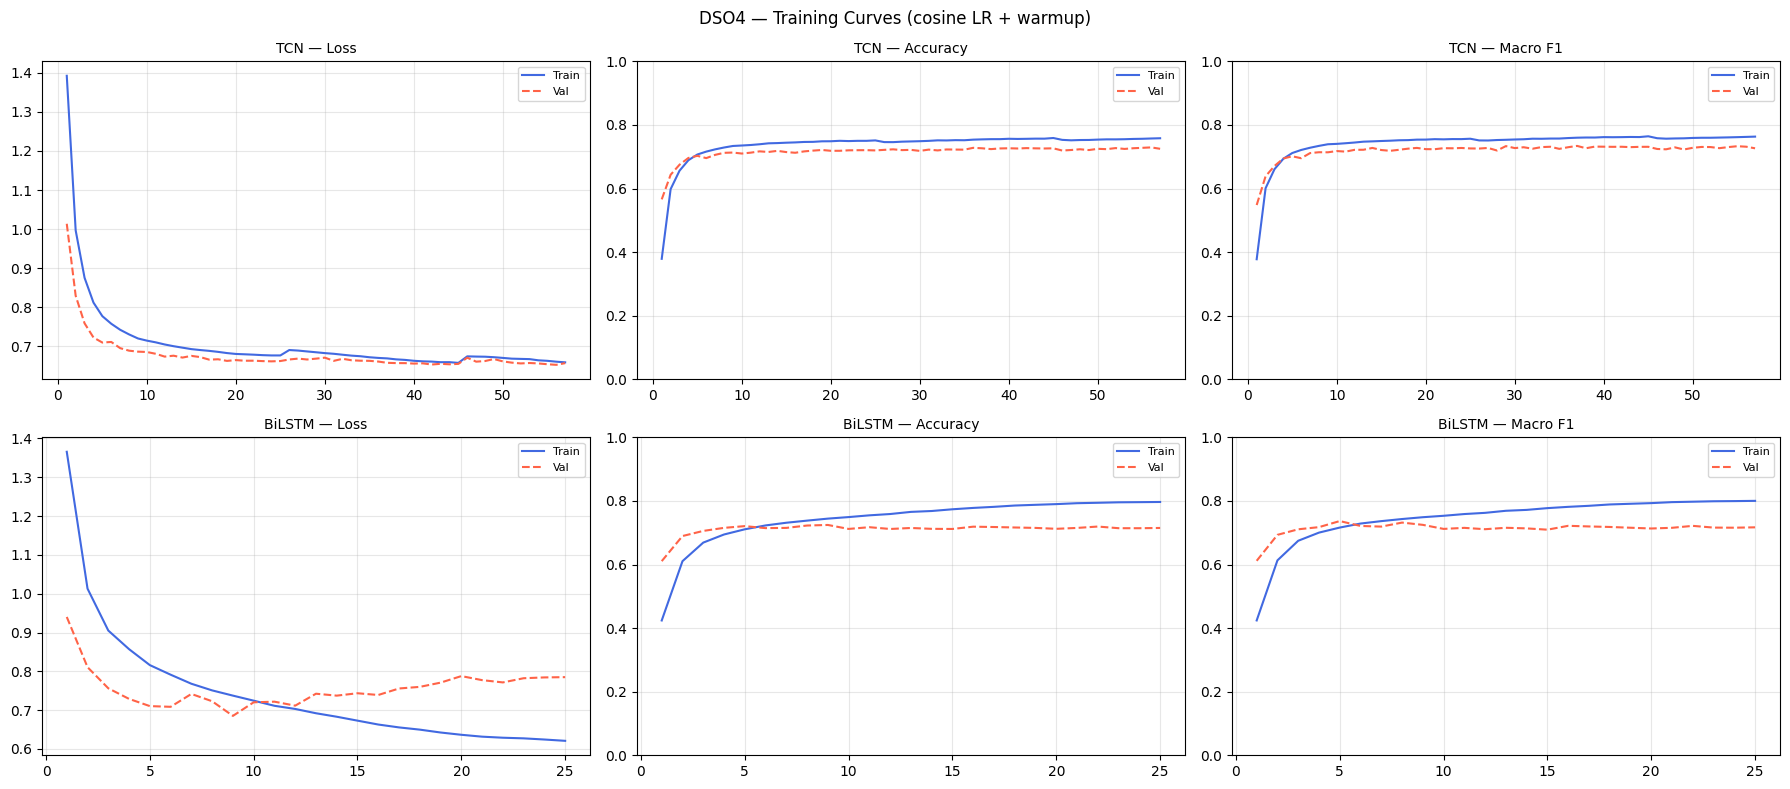

In [13]:
ensemble = EnsembleForecaster(tcn_model, bilstm_model).to(DEVICE)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for row_idx, (hist, name) in enumerate([(tcn_history, 'TCN'), (bilstm_history, 'BiLSTM')]):
    ep = range(1, len(hist['train_loss']) + 1)
    for col, (tr_k, va_k, title) in enumerate([
            ('train_loss', 'val_loss', 'Loss'),
            ('train_acc',  'val_acc',  'Accuracy'),
            ('train_f1',   'val_f1',   'Macro F1'),
        ]):
        ax = axes[row_idx][col]
        ax.plot(ep, hist[tr_k], label='Train', color='royalblue', lw=1.5)
        ax.plot(ep, hist[va_k], label='Val',   color='tomato', ls='--', lw=1.5)
        ax.set_title(f'{name} — {title}', fontsize=10)
        ax.legend(fontsize=8)
        if 'loss' not in tr_k:
            ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

plt.suptitle('DSO4 — Training Curves (cosine LR + warmup)', fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Cell 12b — Weighted Ensemble (replaces the 50/50 EnsembleForecaster)

def get_val_f1(model, val_loader, device):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return f1_score(labels, preds, average='macro', zero_division=0)

# Measure individual val F1 for each model
tcn_f1  = get_val_f1(tcn_model,    val_loader, DEVICE)
lstm_f1 = get_val_f1(bilstm_model, val_loader, DEVICE)
alpha   = tcn_f1 / (tcn_f1 + lstm_f1)

print(f"TCN  val Macro F1 : {tcn_f1:.4f}")
print(f"BiLSTM val Macro F1 : {lstm_f1:.4f}")
print(f"Alpha (TCN weight)  : {alpha:.3f}")
print(f"Beta  (BiLSTM weight): {1-alpha:.3f}")

class WeightedEnsemble(nn.Module):
    def __init__(self, tcn, bilstm, alpha):
        super().__init__()
        self.tcn    = tcn
        self.bilstm = bilstm
        self.alpha  = alpha

    def forward(self, x):
        p_tcn    = F.softmax(self.tcn(x),    dim=1)
        p_bilstm = F.softmax(self.bilstm(x), dim=1)
        return self.alpha * p_tcn + (1 - self.alpha) * p_bilstm

# Overwrite the ensemble variable — Cell 13 will use this automatically
ensemble = WeightedEnsemble(tcn_model, bilstm_model, alpha).to(DEVICE)
print(f"\nWeightedEnsemble ready — replaces the old 50/50 EnsembleForecaster")

In [15]:
def tune_thresholds_global(model, val_loader, y_val, n_classes, device, n_trials=200):
    """Search random threshold combinations, pick best global Macro F1."""
    model.eval()
    with torch.no_grad():
        val_probs = []
        for xb, _ in val_loader:
            p = model(xb.to(device))
            val_probs.append(p.cpu().numpy())
    val_probs = np.concatenate(val_probs)

    best_f1, best_thresholds = -1, np.full(n_classes, 0.5)
    rng = np.random.default_rng(42)

    for _ in range(n_trials):
        # Random threshold vector
        thresholds = rng.uniform(0.10, 0.65, size=n_classes)
        preds = val_probs.argmax(axis=1).copy()
        for cls in range(n_classes):
            preds[val_probs[:, cls] >= thresholds[cls]] = cls
        score = f1_score(y_val, preds, average='macro', zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thresholds = thresholds.copy()

    print(f"Global threshold search best val Macro F1: {best_f1:.4f}")
    return best_thresholds

CLASS_THRESHOLDS = tune_thresholds_global(
    ensemble, val_loader, datasets['y_val'], NUM_CLASSES, DEVICE, n_trials=500
)

Per-class thresholds:
  CALL_DROP                : 0.484
  CAPACITY_EXHAUSTED       : 0.455
  HIGH_LATENCY             : 0.108
  LOW_THROUGHPUT           : 0.137
  NORMAL                   : 0.108
  POOR_VOICE_QUALITY       : 0.455


## Cell 13 — Evaluation

Evaluates each model and the ensemble. For comparison, we also show
the persistence baseline on this exact test set.


In [16]:
def evaluate_model(model, loader, model_name='Model'):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            out = model(xb)
            if isinstance(model, EnsembleForecaster):
                probs = out  # already softmax
            else:
                probs = F.softmax(out, dim=1)
            all_preds.extend(probs.argmax(1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(yb.numpy())

    lat = (time.time() - t0) / len(all_preds) * 1000
    p, l = np.array(all_preds), np.array(all_labels)
    probs_arr = np.array(all_probs)
    return dict(
        preds=p, labels=l, probs=probs_arr,
        acc         = accuracy_score(l, p),
        macro_f1    = f1_score(l, p, average='macro',    zero_division=0),
        weighted_f1 = f1_score(l, p, average='weighted', zero_division=0),
        report      = classification_report(l, p,
                          target_names=label_encoder.classes_, zero_division=0),
        latency_ms  = lat,
        name        = model_name,
    )


# ── Evaluate all ───────────────────────────────────────────────────────────────
results = {}
for mdl, name in [(tcn_model, 'TCN'), (bilstm_model, 'BiLSTM'), (ensemble, 'Ensemble')]:
    r = evaluate_model(mdl, test_loader, name)
    results[name] = r
    h = CFG['horizon']
    print(f'\n{"="*62}')
    print(f'  {name}  |  h=t+{h} (~{h*2}s ahead)')
    print(f'  Accuracy   : {r["acc"]:.4f}')
    print(f'  Macro F1   : {r["macro_f1"]:.4f}   (persistence baseline: {persist_f1:.4f})')
    print(f'  Weighted F1: {r["weighted_f1"]:.4f}')
    print(f'  Latency    : {r["latency_ms"]:.4f} ms/sample')
    print(f'{"="*62}')
    print(r['report'])



  TCN  |  h=t+5 (~10s ahead)
  Accuracy   : 0.7272
  Macro F1   : 0.7365   (persistence baseline: 0.8596)
  Weighted F1: 0.7313
  Latency    : 0.0170 ms/sample
                    precision    recall  f1-score   support

         CALL_DROP       0.68      0.82      0.74      3804
CAPACITY_EXHAUSTED       0.81      0.87      0.84      1900
      HIGH_LATENCY       0.90      0.63      0.74      5988
    LOW_THROUGHPUT       0.54      0.82      0.65      5444
            NORMAL       0.84      0.71      0.77     10100
POOR_VOICE_QUALITY       0.72      0.64      0.68      4572

          accuracy                           0.73     31808
         macro avg       0.75      0.75      0.74     31808
      weighted avg       0.76      0.73      0.73     31808


  BiLSTM  |  h=t+5 (~10s ahead)
  Accuracy   : 0.7215
  Macro F1   : 0.7391   (persistence baseline: 0.8596)
  Weighted F1: 0.7298
  Latency    : 0.0198 ms/sample
                    precision    recall  f1-score   support

         CA

In [17]:
# Post-training feature usefulness diagnostics (sparsity + permutation importance).

def macro_f1_on_numpy(model, X, y, batch_size=512):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32, device=DEVICE)
            out = model(xb)
            probs = out if isinstance(model, EnsembleForecaster) else F.softmax(out, dim=1)
            preds.extend(probs.argmax(1).cpu().numpy())
    return f1_score(y, np.array(preds), average='macro', zero_division=0)


def compute_permutation_importance(
    model, X_val, y_val, feature_names, repeats=5, max_features=None, seed=SEED
):
    rng = np.random.default_rng(seed)
    baseline_f1 = macro_f1_on_numpy(model, X_val, y_val)

    feature_indices = np.arange(X_val.shape[2])
    if max_features is not None and int(max_features) < len(feature_indices):
        train_var = np.var(datasets['X_train'].reshape(-1, datasets['X_train'].shape[2]), axis=0)
        feature_indices = np.argsort(train_var)[::-1][:int(max_features)]

    rows = []
    for j in feature_indices:
        drops = []
        for _ in range(int(repeats)):
            X_perm = X_val.copy()
            perm = rng.permutation(len(X_perm))
            # Permute feature-channel across windows; keep each window sequence intact.
            X_perm[:, :, j] = X_perm[perm, :, j]
            f1_perm = macro_f1_on_numpy(model, X_perm, y_val)
            drops.append(baseline_f1 - f1_perm)

        rows.append(dict(
            feature=feature_names[j],
            importance=float(np.mean(drops)),
            importance_std=float(np.std(drops)),
        ))

    imp_df = pd.DataFrame(rows).sort_values('importance', ascending=False).reset_index(drop=True)
    return baseline_f1, imp_df


X_train_flat = datasets['X_train'].reshape(-1, datasets['X_train'].shape[2])
feat_variance = np.var(X_train_flat, axis=0)
feat_sparsity = np.mean(np.isclose(X_train_flat, 0.0, atol=1e-6), axis=0)

feature_diag_df = pd.DataFrame({
    'feature': feat_cols,
    'variance': feat_variance,
    'sparsity': feat_sparsity,
})
feature_diag_df['near_zero_var'] = feature_diag_df['variance'] < CFG['variance_threshold']
feature_diag_df.to_csv('artifacts/feature_diagnostics.csv', index=False)

print('\nFeature diagnostics (train windows):')
print(f"  Features: {len(feat_cols)}")
print(f"  Near-zero variance (<{CFG['variance_threshold']}): {int(feature_diag_df['near_zero_var'].sum())}")
print(f"  Highly sparse (>95% near-zero): {int((feature_diag_df['sparsity'] > 0.95).sum())}")

baseline_val_f1_perm, feature_imp_df = compute_permutation_importance(
    bilstm_model,
    datasets['X_val'],
    datasets['y_val'],
    feat_cols,
    repeats=CFG['importance_num_repeats'],
    max_features=CFG['importance_max_features'],
    seed=SEED,
)
feature_imp_df.to_csv('artifacts/feature_importance.csv', index=False)

drop_th = float(CFG.get('importance_drop_threshold', 0.0))
low_impact_candidates = feature_imp_df[
    (feature_imp_df['importance'] <= drop_th)
    & ((feature_imp_df['importance'] + feature_imp_df['importance_std']) <= drop_th)
]['feature'].tolist()
with open('artifacts/low_impact_feature_candidates.json', 'w') as f:
    json.dump(low_impact_candidates, f, indent=2)

print(f"\nPermutation-importance baseline val Macro F1 (BiLSTM): {baseline_val_f1_perm:.4f}")
print(f"Importance repeats: {CFG['importance_num_repeats']}")
print(f"Low-impact candidate count (threshold={drop_th}): {len(low_impact_candidates)}")
print('\nTop 10 useful features:')
print(feature_imp_df.head(10).to_string(index=False))
print('\nBottom 10 low-impact features:')
print(feature_imp_df.tail(10).to_string(index=False))



Feature diagnostics (train windows):
  Features: 23
  Near-zero variance (<0.0001): 0
  Highly sparse (>95% near-zero): 1

Permutation-importance baseline val Macro F1 (BiLSTM): 0.7366
Importance repeats: 7
Low-impact candidate count (threshold=0.0): 0

Top 10 useful features:
               feature  importance  importance_std
    call_setup_time_ms    0.144576        0.001270
          e2e_delay_ms    0.118924        0.002524
   video_start_time_ms    0.101582        0.001067
 throughput_mbps_rstd5    0.092825        0.001577
  dataplane_latency_ms    0.089684        0.002039
             mos_voice    0.063858        0.001183
             jitter_ms    0.041133        0.000687
            flow_count    0.031464        0.000711
throughput_mbps_rstd10    0.024350        0.000567
       mos_voice_rstd5    0.021477        0.000663

Bottom 10 low-impact features:
            feature  importance  importance_std
  dataplane_missing    0.003703        0.000177
e2e_delay_ms_rstd10    0.003533 

## Cell 14 — Confusion Matrix & Per-Class F1

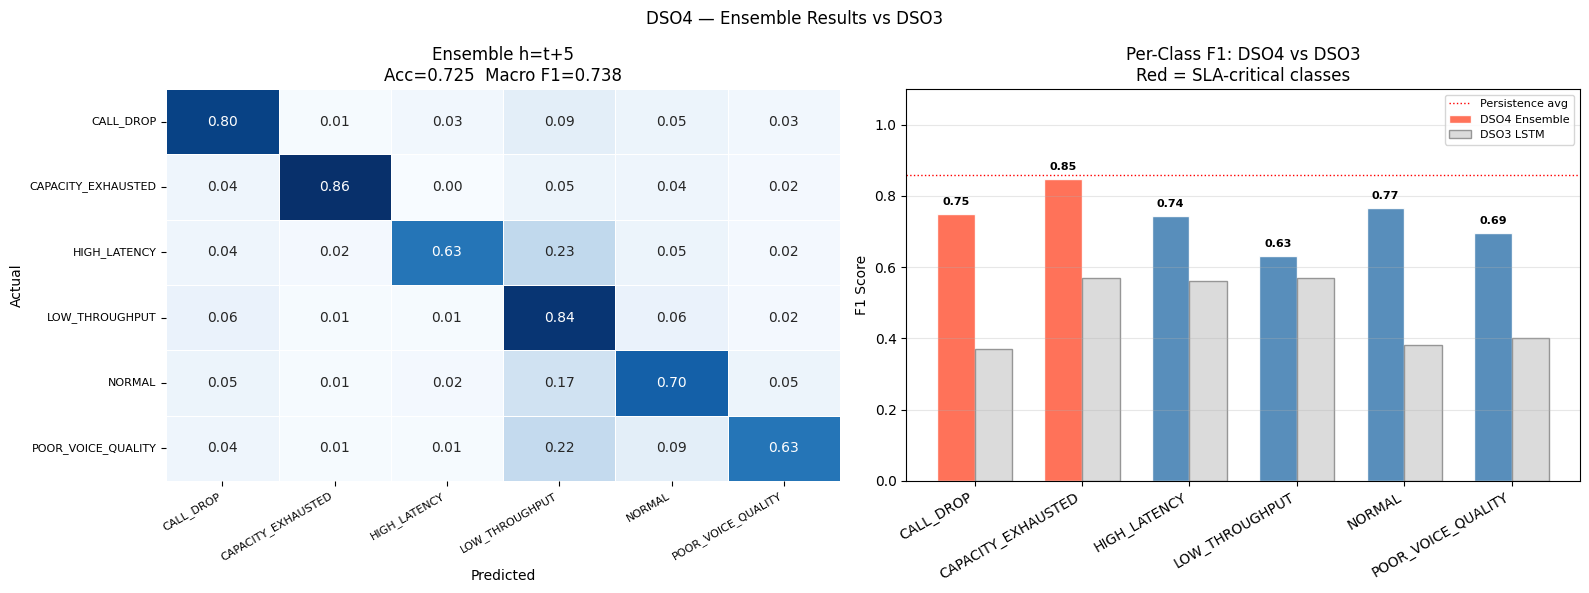

In [18]:
r = results['Ensemble']
h = CFG['horizon']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm      = confusion_matrix(r['labels'], r['preds'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(np.round(cm_norm, 2), ax=axes[0], annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.4, cbar=False,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[0].set_title(f'Ensemble h=t+{h}\nAcc={r["acc"]:.3f}  Macro F1={r["macro_f1"]:.3f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(label_encoder.classes_, rotation=30, ha='right', fontsize=8)
axes[0].set_yticklabels(label_encoder.classes_, rotation=0, fontsize=8)

# Per-class F1 with comparison to DSO3
pc_f1_new = f1_score(r['labels'], r['preds'], average=None, zero_division=0,
                     labels=np.arange(NUM_CLASSES))
dso3_f1 = {'CALL_DROP': 0.37, 'CAPACITY_EXHAUSTED': 0.57, 'HIGH_LATENCY': 0.56,
           'LOW_THROUGHPUT': 0.57, 'NORMAL': 0.38, 'POOR_VOICE_QUALITY': 0.40}

x   = np.arange(NUM_CLASSES)
w   = 0.35
colors_new = ['tomato' if cls in CFG['minority_boost_classes'] else 'steelblue'
              for cls in label_encoder.classes_]
bars1 = axes[1].bar(x - w/2, pc_f1_new, w, color=colors_new,
                    edgecolor='white', alpha=0.9, label='DSO4 Ensemble')
bars2 = axes[1].bar(x + w/2,
                    [dso3_f1.get(cls, 0) for cls in label_encoder.classes_], w,
                    color='lightgray', edgecolor='gray', alpha=0.8, label='DSO3 LSTM')

axes[1].axhline(persist_f1 / NUM_CLASSES * NUM_CLASSES, color='red',
                ls=':', lw=1, label=f'Persistence avg')
axes[1].set_ylabel('F1 Score'); axes[1].set_ylim(0, 1.1)
axes[1].set_title('Per-Class F1: DSO4 vs DSO3\nRed = SLA-critical classes')
axes[1].set_xticks(x); axes[1].set_xticklabels(label_encoder.classes_, rotation=30, ha='right')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)
for bar in bars1:
    yv = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yv + 0.02, f'{yv:.2f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('DSO4 — Ensemble Results vs DSO3', fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/confusion_and_f1.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 15 — SLA Risk Detection

Same threshold-based risk score as DSO3 but now using ensemble probabilities,
which are better calibrated than a single LSTM's logits.


=== SLA Early Warning (θ=0.3) ===
  Horizon        : t+5 (~10s ahead of event)
  Alerts raised  : 6,945 / 31,808 (21.8% of samples)
  True violations: 5,704 (17.9% of samples)

  Alert Precision: 0.711
  Alert Recall   : 0.866
  Alert F1       : 0.781


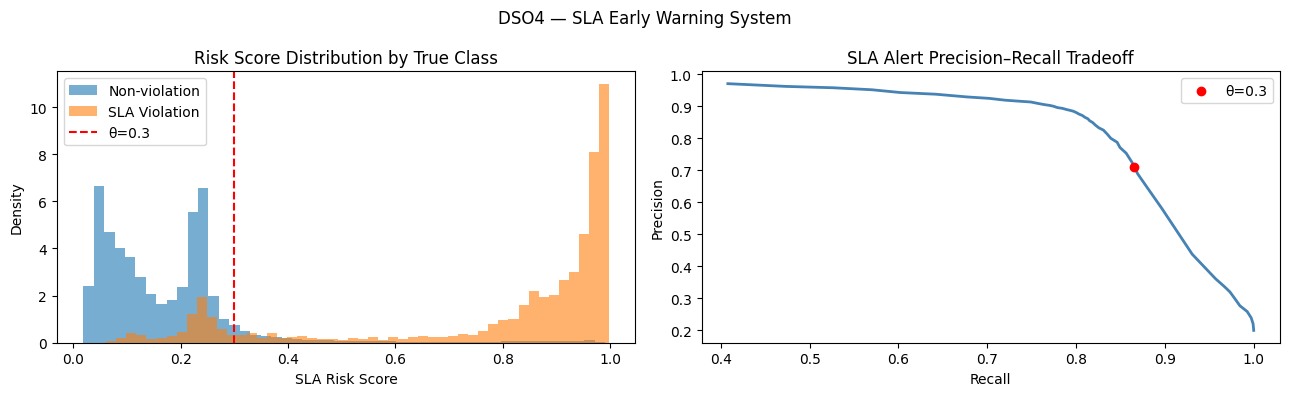

In [19]:
SLA_RISK_CLASSES  = ['CALL_DROP', 'CAPACITY_EXHAUSTED']
SLA_RISK_INDICES  = [int(np.where(label_encoder.classes_ == c)[0])
                     for c in SLA_RISK_CLASSES if c in label_encoder.classes_]
ALERT_THRESHOLD   = 0.30

probs          = r['probs']
risk_score     = probs[:, SLA_RISK_INDICES].sum(axis=1)
alert_flag     = risk_score > ALERT_THRESHOLD
true_violations = np.isin(r['labels'], SLA_RISK_INDICES)

TP = (alert_flag  & true_violations).sum()
FP = (alert_flag  & ~true_violations).sum()
FN = (~alert_flag & true_violations).sum()

precision_alert = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_alert    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_alert        = (2 * precision_alert * recall_alert /
                   (precision_alert + recall_alert + 1e-8))

print(f'=== SLA Early Warning (θ={ALERT_THRESHOLD}) ===')
print(f'  Horizon        : t+{h} (~{h*2}s ahead of event)')
print(f'  Alerts raised  : {alert_flag.sum():,} / {len(alert_flag):,} '
      f'({alert_flag.mean()*100:.1f}% of samples)')
print(f'  True violations: {true_violations.sum():,} '
      f'({true_violations.mean()*100:.1f}% of samples)')
print(f'')
print(f'  Alert Precision: {precision_alert:.3f}')
print(f'  Alert Recall   : {recall_alert:.3f}')
print(f'  Alert F1       : {f1_alert:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label_name, mask in [('Non-violation', ~true_violations), ('SLA Violation', true_violations)]:
    axes[0].hist(risk_score[mask], bins=50, alpha=0.6, label=label_name, density=True)
axes[0].axvline(ALERT_THRESHOLD, color='red', ls='--', lw=1.5, label=f'θ={ALERT_THRESHOLD}')
axes[0].set_xlabel('SLA Risk Score'); axes[0].set_ylabel('Density')
axes[0].set_title('Risk Score Distribution by True Class'); axes[0].legend()

thresholds = np.linspace(0.05, 0.95, 50)
precs, recs = [], []
for th in thresholds:
    af  = risk_score > th
    tp_ = (af & true_violations).sum()
    fp_ = (af & ~true_violations).sum()
    fn_ = (~af & true_violations).sum()
    precs.append(tp_ / (tp_ + fp_ + 1e-8))
    recs.append(tp_  / (tp_ + fn_ + 1e-8))
axes[1].plot(recs, precs, color='steelblue', lw=2)
axes[1].scatter([recall_alert], [precision_alert], color='red', zorder=5, label=f'θ={ALERT_THRESHOLD}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('SLA Alert Precision–Recall Tradeoff'); axes[1].legend()
plt.suptitle('DSO4 — SLA Early Warning System', fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/sla_risk.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 16 — Save All Artefacts

In [ ]:
torch.save(tcn_model.state_dict(),    'artifacts/tcn_final.pt')
torch.save(bilstm_model.state_dict(), 'artifacts/bilstm_final.pt')
joblib.dump(label_encoder, 'artifacts/label_encoder.pkl')
joblib.dump(seg_encoder,   'artifacts/seg_encoder.pkl')
with open('artifacts/feature_columns.json', 'w') as f:
    json.dump(feat_cols, f, indent=2)
with open('artifacts/cfg.json', 'w') as f:
    json.dump(CFG, f, indent=2)
with open('artifacts/model_feature_columns.json', 'w') as f:
    json.dump({
        'TCNForecaster': feat_cols,
        'BiLSTMForecaster': feat_cols,
        'feature_count': INPUT_SIZE,
    }, f, indent=2)

# Keep the preprocessing artifact in sync with the final selected training features.
if 'preprocess_artifacts' in globals():
    preprocess_artifacts['selected_feature_columns'] = feat_cols
    preprocess_artifacts['feature_columns_used_for_training'] = feat_cols
    preprocess_artifacts['removed_feature_columns'] = removed_features
    joblib.dump(preprocess_artifacts, 'artifacts/preprocess_artifacts.joblib')
else:
    print('Warning: preprocess_artifacts not found in memory; run preprocessing cell before final save.')

# Summary
print('\n' + '=' * 60)
print('  DSO4 Summary')
print('=' * 60)
print(f'  Persistence baseline  : Macro F1 = {persist_f1:.4f}')
for name, res in (results.items() if 'results' in dir() else {}.items()):
    delta = res['macro_f1'] - persist_f1
    sign = '+' if delta > 0 else ''
    print(f"  {name:<22}: Macro F1 = {res['macro_f1']:.4f}  ({sign}{delta:.4f} vs baseline)")
print()
print('  Artefacts saved to artifacts/:')
print('    tcn_final.pt, bilstm_final.pt — model weights')
print('    label_encoder.pkl, seg_encoder.pkl')
print('    feature_columns.json, model_feature_columns.json')
print('    preprocess_artifacts.joblib, cfg.json')
print('    removed_features.json, feature_diagnostics.csv, feature_importance.csv')
print('    low_impact_feature_candidates.json')
if os.path.exists('artifacts/optuna_bilstm_study.csv'):
    print('    optuna_bilstm_study.csv, best_bilstm_params.json')
